# Design and implementation of the codec

In [1]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import soundfile as sf
from matplotlib import pyplot as plt
from numpy.fft import rfft
from scipy.linalg import solve_toeplitz
from scipy.signal import get_window, lfilter, filtfilt, firwin

# Selection of the parameter values

In [2]:
LPC_ORDER = 10
ACORR_WIN = "hamming"  # tukey is better but ok
FRAME_LENGTH = 0.025
FFT_N = 1024

In [3]:
DATA_MALE_PATH = Path("Male_sentences_8kHz")
DATA_FEMALE_PATH = Path("Female_sentences_8kHz")
EXAMPLE_MALE_PATH = DATA_MALE_PATH / "si745_8kHz.wav"
EXAMPLE_FEMALE_PATH = DATA_FEMALE_PATH / "si747_8kHz.wav"

# LP analysis and synthesis without quantization

Small change from the original suggestion - store the warm-up samples inside the residual as this makes the whole process easier and doesn't involve the use of zi or other operations including Z-transforms that might affect accuracy

In [4]:
def autocorr(signal: np.array, target_len: int) -> np.array:
    """
    Computes autocorrelation
    :param signal: signal to be autocorrelated
    :param target_len: number of coefficients
    :return: autocorrelation coefficients
    """
    return np.asarray([signal[:len(signal) - i].dot(signal[i:]) for i in range(target_len)])


def calculate_lpc_coefficients(signal: np.ndarray, order: int) -> np.ndarray:
    """
    Calculates LPC coefficents
    :param signal: input signal to calculate LPC coefficients from
    :param order: LPC order
    :return: LPC coefficients as filter parameters suitable for lfilter
    """
    window = get_window(ACORR_WIN, len(signal))
    r = autocorr(signal * window, order + 1)

    lpc_raw = solve_toeplitz(r[:-1], r[1:], check_finite=False)

    # add a x1 coefficient for the current sample and invert the LPC so we subtract the predicted sum
    # using LPC with these coefficients will result in the residual without any necessary subtraction step
    # this also allows for inverse filtering even without setting initial values for the delay line
    # (since the warm-up samples are still in the residual - see beginning of example frame residual)
    return np.pad(-lpc_raw, (1, 0), constant_values=1)


def compute_residual(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter(lpc_c, [1], signal)


def restore_signal(signal: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return lfilter([1], lpc_c, signal)

In [5]:
def lpc_analysis(frame: np.ndarray) -> (np.ndarray, np.ndarray):
    lpc_c = calculate_lpc_coefficients(frame, LPC_ORDER)
    residual = compute_residual(frame, lpc_c)
    return residual, lpc_c


def lpc_synthesis(frame_residual: np.ndarray, lpc_c: np.ndarray) -> np.ndarray:
    return restore_signal(frame_residual, lpc_c)


def process_frame(frame: np.ndarray) -> Dict[str, np.ndarray]:
    resid, lpc_c = lpc_analysis(frame)
    restored = lpc_synthesis(resid, lpc_c)
    return {"Frame": frame, "LPC Coefficients": lpc_c, "Residual": resid, "Synthetized Frame": restored}

In [6]:
def lpc(file_path: Path):
    with sf.SoundFile(file_path, "r") as f:
        sr = f.samplerate
        frames = list(f.blocks(blocksize=int(sr * FRAME_LENGTH), dtype="float64"))

    if len(frames[0].shape) != 1:
        raise RuntimeError("This codec only supports mono audio")

    return pd.DataFrame.from_records([process_frame(f) for f in frames])


df_lpc_male = lpc(EXAMPLE_MALE_PATH)
df_lpc_female = lpc(EXAMPLE_FEMALE_PATH)

### Plot one nice speech frame for comparison

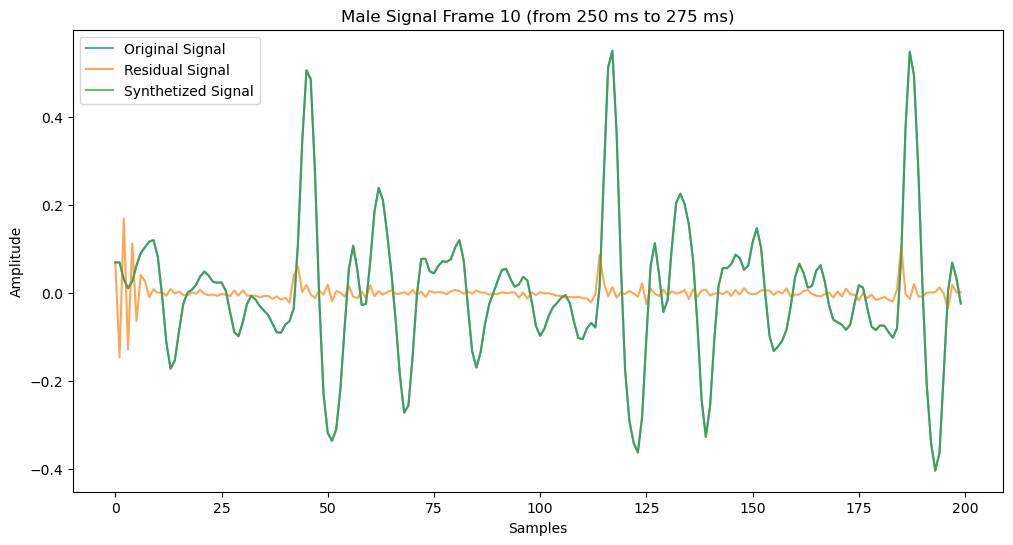

In [7]:
example_frame_idx = 10

plt.figure(figsize=(12, 6))
plt.plot(df_lpc_male.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df_lpc_male.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df_lpc_male.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Male Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Plot whole signal as the assignment requires

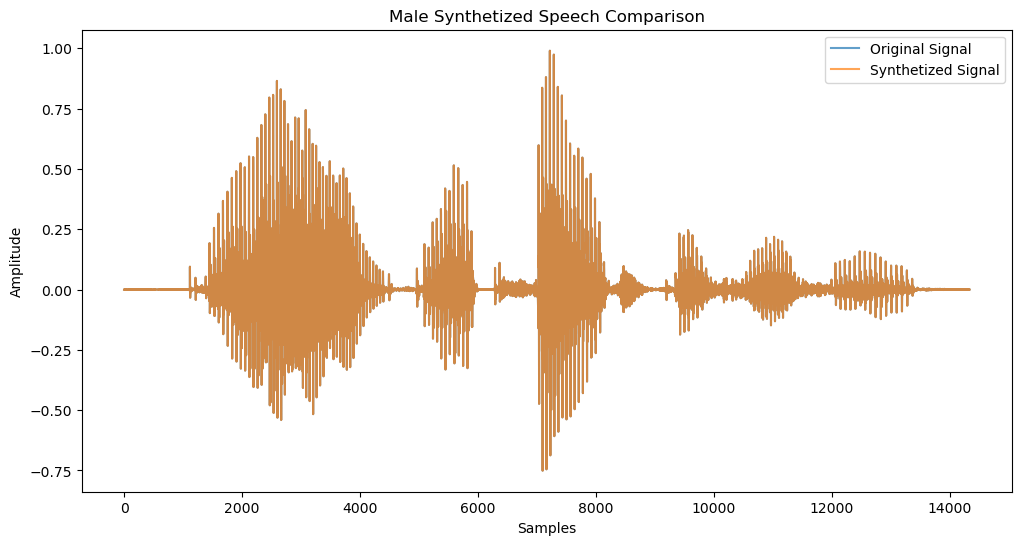

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_lpc_male["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_lpc_male["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Male Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Differences
Just to illustrate the similarity better, let's plot the max difference between the original and the synthetized signal in each frame

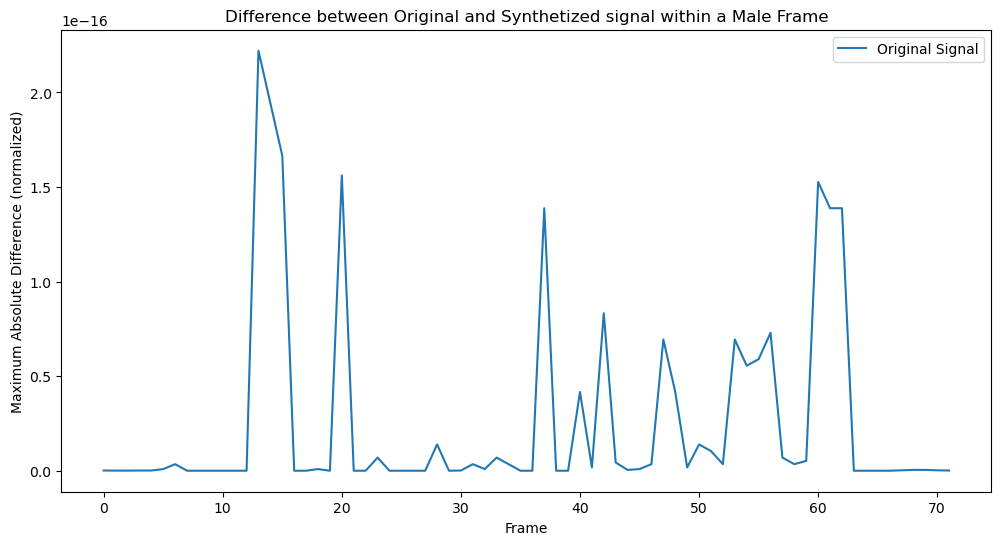

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df_lpc_male.apply(lambda x: abs(x["Frame"] - x["Synthetized Frame"]).max(), axis=1), label="Original Signal")
plt.legend()
plt.title("Difference between Original and Synthetized signal within a Male Frame")
plt.xlabel("Frame")
plt.ylabel("Maximum Absolute Difference (normalized)")
plt.show()

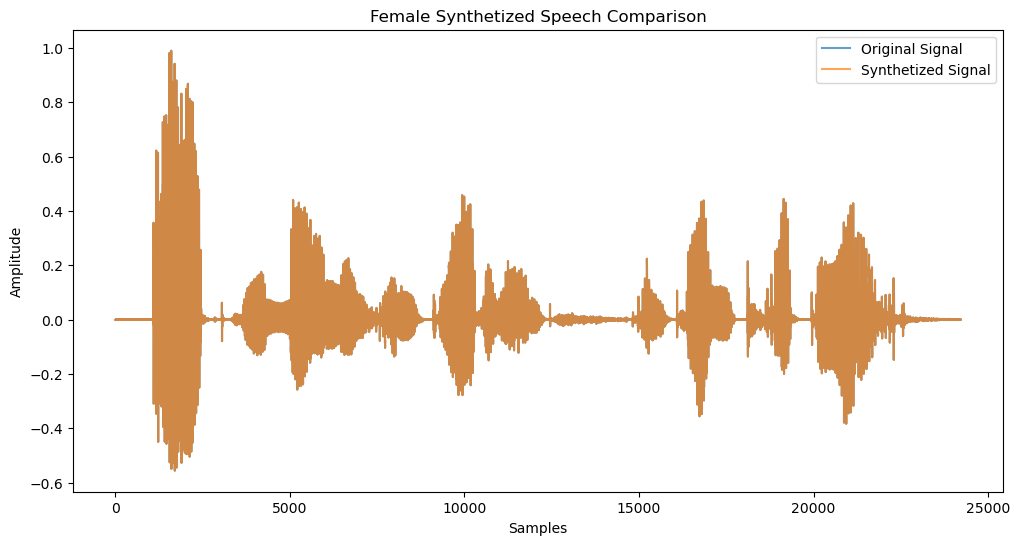

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_lpc_female["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_lpc_female["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Female Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

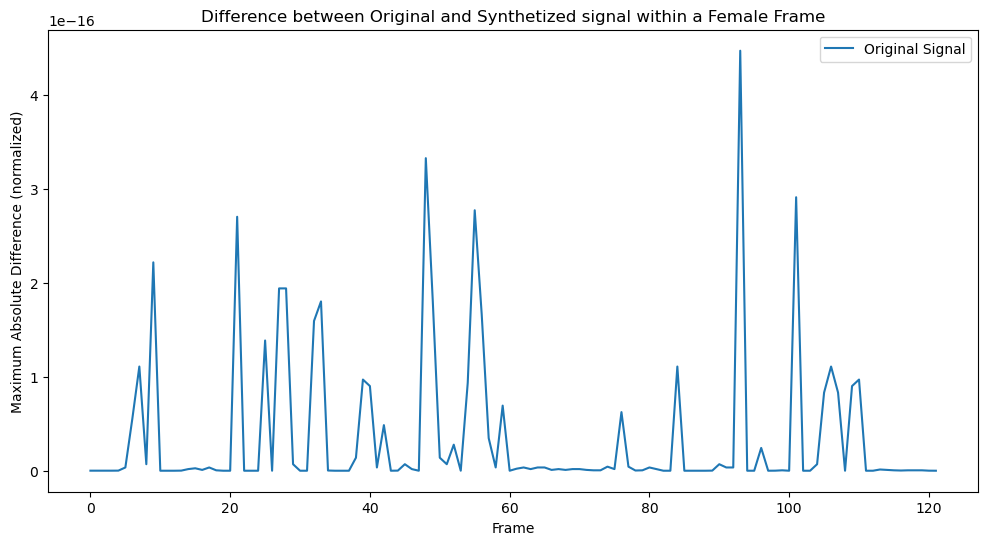

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(df_lpc_female.apply(lambda x: abs(x["Frame"] - x["Synthetized Frame"]).max(), axis=1), label="Original Signal")
plt.legend()
plt.title("Difference between Original and Synthetized signal within a Female Frame")
plt.xlabel("Frame")
plt.ylabel("Maximum Absolute Difference (normalized)")
plt.show()

# Quantization of the LP filter

In [12]:
def sdsq(lpc_c: np.ndarray, qlp_c: np.ndarray) -> np.float64:
    po = abs(rfft(lpc_c, n=FFT_N))**2
    pq = abs(rfft(qlp_c, n=FFT_N))**2
    return np.mean((10*np.log10(po) - 10*np.log10(pq))**2)

def sd(lpc_c: np.ndarray, qlp_c: np.ndarray) -> np.float64:
    return np.sqrt(sdsq(lpc_c, qlp_c))

In [13]:
def lpc_to_lattice(a):
    """
    Convert LPC coefficients to lattice (reflection/PARCOR) coefficients.
    :param a: 1D array of LPC coefficients (including leading 1)
    :return: 1D array of reflection coefficients
    """
    a = np.array(a, dtype=np.float64)
    order = len(a) - 1
    k = np.zeros(order)

    for m in range(order, 0, -1):
        k[m - 1] = a[m]
        if abs(k[m - 1]) >= 1:
            raise ValueError("Unstable filter: reflection coefficient magnitude ≥ 1")

        a_temp = np.copy(a[:m])
        for i in range(m - 1):
            a[i + 1] = (a_temp[i + 1] - k[m - 1] * a_temp[m - i - 1]) / (1.0 - k[m - 1]**2)

    return k

def lattice_to_lpc(k):
    """
    Convert reflection (PARCOR) coefficients to LPC synthesis filter coefficients.
    :param k: 1D array of reflection coefficients
    :return: 1D array of LPC coefficients (including leading 1)
    """
    order = len(k)
    a = np.zeros(order + 1)
    a[0] = 1.0

    for i in range(order):
        ki = k[i]
        a_prev = a.copy()
        for j in range(1, i + 1):
            a[j] = a_prev[j] + ki * a_prev[i - j + 1]
        a[i + 1] = ki

    return a

In [14]:
def uniform_quantize(x: (float, np.ndarray), bits: int, min_val=-1.0, max_val=1.0):
    """
    Quantize number or array using Uniform Quantization.

    :param x: The input value(s) to be quantized. Must be within [min_val, max_val].
    :param bits: The number of bits to use for quantization. Determines the number of quantization levels.
    :param min_val: The minimum value of the quantization range. Defaults to -1.0.
    :param max_val: The maximum value of the quantization range. Defaults to 1.0.
    :return: Each input as mapped to the nearest of 2**bits levels between min_val and max_val.
    """
    assert x.min() >= min_val
    assert x.max() <= max_val

    levels = 2 ** bits
    step_size = (max_val - min_val) / (levels - 1)
    x_clipped = np.clip(x, min_val, max_val)
    quant_indices = np.round((x_clipped - min_val) / step_size)
    return min_val + quant_indices * step_size

def quantize_lattice(k: np.ndarray, bits: int) -> np.ndarray:
    """
    Quantize lattice reflection coefficients using uniform scalar quantization.

    :param k: 1D array of reflection coefficients
    :param bits: number of bits per coefficient
    :return: quantized coefficients (dequantized float values)
    """
    max_val = 0.999  # slightly less than 1 to maintain stability
    min_val = -max_val

    return uniform_quantize(k, bits, min_val=min_val, max_val=max_val)

In [15]:
def quantize_lpc(lpc_c: np.ndarray, n_bits: int) -> np.ndarray:
    lattice_c = lpc_to_lattice(lpc_c)
    quantized_lattice = quantize_lattice(lattice_c, n_bits)
    return lattice_to_lpc(quantized_lattice)

def quantized_lpc_distortion(lpc_c: np.ndarray, n_bits: int) -> np.float64:
    qlp_c = quantize_lpc(lpc_c, n_bits)
    return sd(lpc_c, qlp_c)

def calculate_spectral_distortions(row: pd.Series, num_bits_list=(5, 4, 3)):
    for bits in num_bits_list:
        row[f"SD for {bits} bits"] = quantized_lpc_distortion(row["LPC Coefficients"], bits)
    return row

df_lpc_male_distortions = df_lpc_male.apply(calculate_spectral_distortions, axis=1)
df_lpc_female_distortions = df_lpc_female.apply(calculate_spectral_distortions, axis=1)

In [16]:
def print_sd_avg(df: pd.DataFrame, num_bits_list=(5, 4, 3)):
    for bits in num_bits_list:
        colname = f"SD for {bits} bits"
        print(f"Average SD for {bits} bits: {df[colname].mean():.3f}")

print(f"Average distortions:")
print(f"=== File: {EXAMPLE_MALE_PATH} ===")
print_sd_avg(df_lpc_male_distortions)
print(f"=== File: {EXAMPLE_FEMALE_PATH} ===")
print_sd_avg(df_lpc_female_distortions)

Average distortions:
=== File: Male_sentences_8kHz/si745_8kHz.wav ===
Average SD for 5 bits: 0.904
Average SD for 4 bits: 1.664
Average SD for 3 bits: 4.367
=== File: Female_sentences_8kHz/si747_8kHz.wav ===
Average SD for 5 bits: 1.236
Average SD for 4 bits: 2.456
Average SD for 3 bits: 4.526


# Test to see if the quantized LPC coefficients still work

In [17]:
def qlp_analysis(frame: np.ndarray, n_bits) -> (np.ndarray, np.ndarray):
    lpc_c = calculate_lpc_coefficients(frame, LPC_ORDER)
    qlp_c = quantize_lpc(lpc_c, n_bits=n_bits)
    residual = compute_residual(frame, qlp_c)
    return residual, qlp_c

def process_frame_quantized(frame: np.ndarray, n_bits=3) -> Dict[str, np.ndarray]:
    resid, qlp_c = qlp_analysis(frame, n_bits=n_bits)
    restored = lpc_synthesis(resid, qlp_c)
    return {"Frame": frame, "LPC Coefficients": qlp_c, "Residual": resid, "Synthetized Frame": restored}

In [18]:
def qlp(file_path: Path):
    with sf.SoundFile(file_path, "r") as f:
        sr = f.samplerate
        frames = list(f.blocks(blocksize=int(sr * FRAME_LENGTH), dtype="float64"))

    if len(frames[0].shape) != 1:
        raise RuntimeError("This codec only supports mono audio")

    return pd.DataFrame.from_records([process_frame_quantized(f) for f in frames])


df_qlp_male = qlp(EXAMPLE_MALE_PATH)
df_qlp_female = qlp(EXAMPLE_FEMALE_PATH)

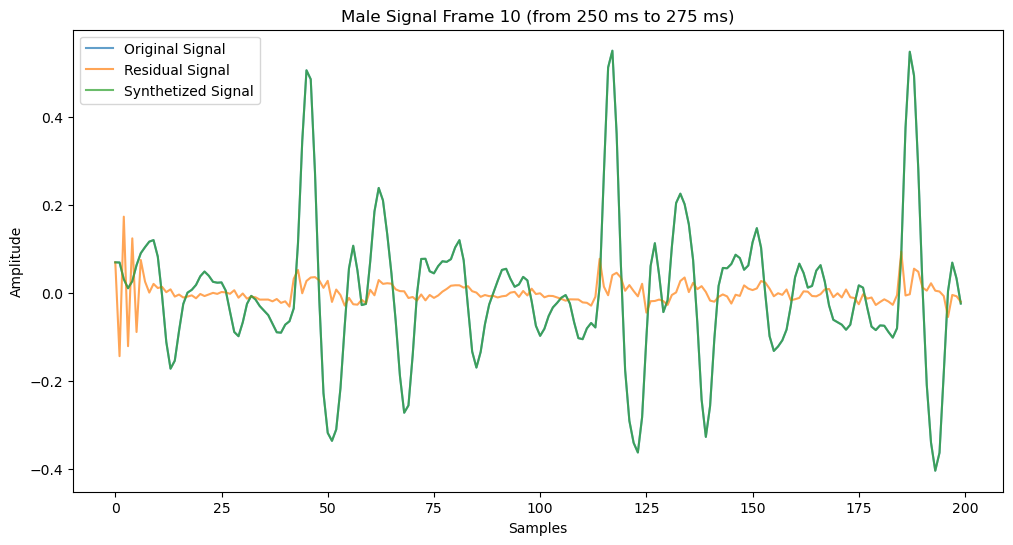

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df_qlp_male.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df_qlp_male.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df_qlp_male.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Male Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

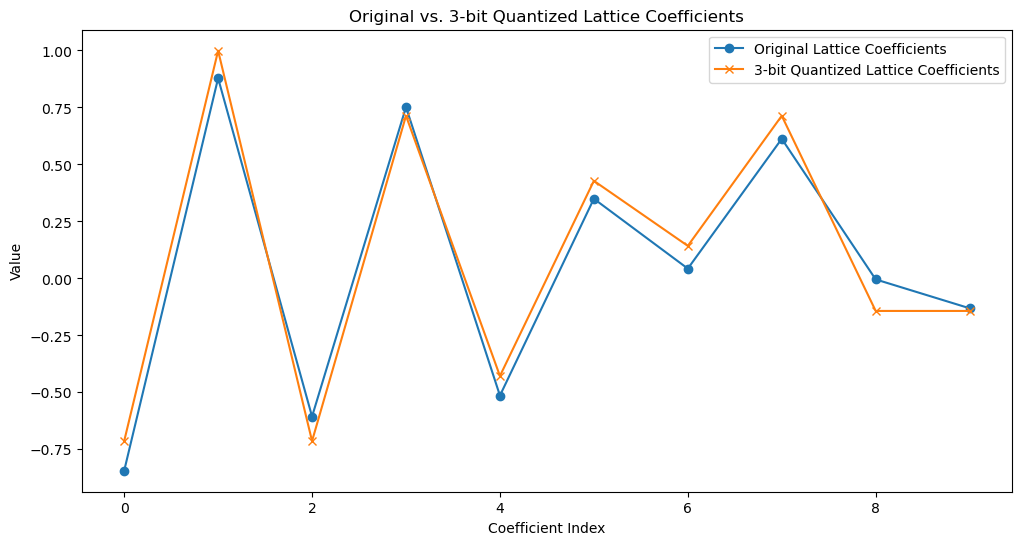

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(lpc_to_lattice(df_lpc_male.loc[example_frame_idx, "LPC Coefficients"]), label='Original Lattice Coefficients', marker='o')
plt.plot(lpc_to_lattice(df_qlp_male.loc[example_frame_idx, "LPC Coefficients"]), label='3-bit Quantized Lattice Coefficients', marker='x')
plt.legend()
plt.title('Original vs. 3-bit Quantized Lattice Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.show()

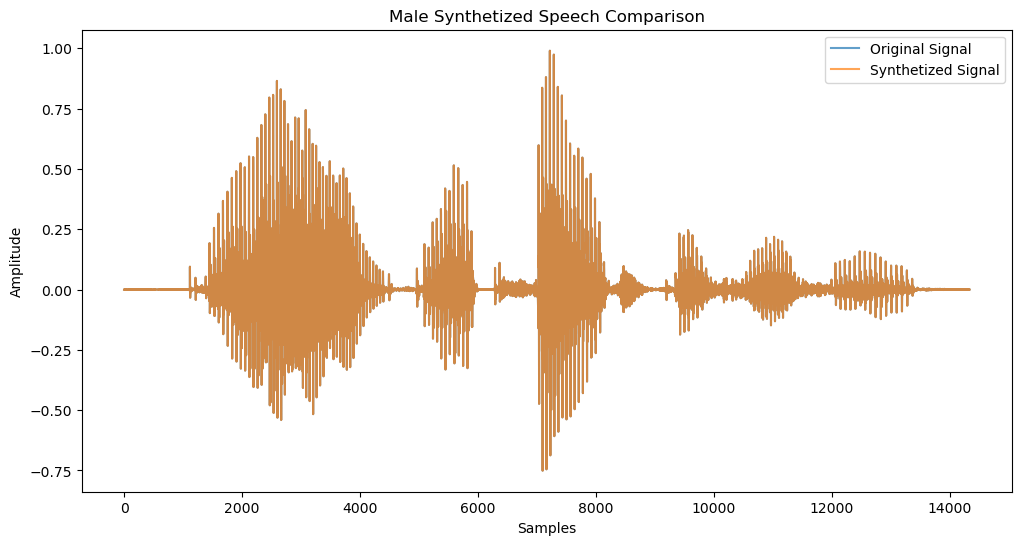

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_qlp_male["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_qlp_male["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Male Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

# Implementation of the codec

First define elemental functions that perform one operation on a single frame

In [22]:
LOWPASS_COEFFS = np.array([
    -0.01635742,
    -0.04565430,
     0.0,
     0.25073242,
     0.70080566,
     1.0,
     0.70080566,
     0.25073242,
     0.0,
    -0.04565430,
    -0.01635742
])

def lowpass_residual(residual: np.ndarray, sample_rate: int) -> np.ndarray:
    if len(residual) < int(FRAME_LENGTH*sample_rate):
        # too small frame, no need to filter
        return residual
    return filtfilt(LOWPASS_COEFFS, [1.0], residual)

def normalize_residual(residual: np.ndarray, n_bits: int) -> (np.ndarray, np.float64):
    qmax = uniform_quantize(residual.max(), bits=n_bits, max_val=10.0, min_val=-10.0)
    return np.clip(residual / qmax, a_min=-1.0, a_max=1.0), qmax

def decimate_signal(signal: np.ndarray, start: int, order: int = 3) -> np.ndarray:
    result = signal.copy()
    mask = np.full(result.shape, True)
    offset = order - start
    end = -offset if offset > 0 else None
    mask[start:end:order] = False
    result[mask] = 0
    return result

def decimate_residual(residual: np.ndarray, decimations = (0, 1, 2, 3)) -> (np.ndarray, int):
    dres = [decimate_signal(residual, d) for d in decimations]
    energies = map(lambda x: np.sum(np.square(x)), dres)
    chosen = np.argmax(energies)
    return dres[chosen], chosen


Next define what happens with a single frame

Also note: we are currently not storing the data between the encoder and decoder, just calculating the exact budget and simulating feeding the output after io into the decoder - the result is the same as if we would store it

Question: should we actually store the data in a bitstream or is simulation enough? (since the resulting wav is the same)

In [23]:
QLP_BITS = 6
NORM_BITS = 16
RESID_BITS = 3

def process_frame_codec(frame: np.ndarray, sr: int) -> Dict[str, np.ndarray]:
    ### Special case for extremely short frames ###
    if len(frame) < LPC_ORDER:
        # these few samples are just saved raw with PCM16
        return {
        "Frame": frame,
        "LPC Coefficients": None,
        "Residual": frame,
        "Synthetized Frame": frame,
        "Budget": len(frame) * 16
    }
    
    ### Encoding part ###
    resid, qlp_c = qlp_analysis(frame, n_bits=QLP_BITS)
    resid = lowpass_residual(resid, sr)
    resid, qmax = normalize_residual(resid, n_bits=NORM_BITS)
    resid, decimation_chosen = decimate_residual(resid)

    mask = resid != 0
    resid[mask] = uniform_quantize(resid[mask], bits=RESID_BITS, max_val=1.0, min_val=-1.0)

    ### Decoding part ###

    resid *= qmax
    restored = lpc_synthesis(resid, qlp_c)

    ### Calculate budget ###
    budget = (len(qlp_c) * QLP_BITS) + NORM_BITS + (np.count_nonzero(resid) * RESID_BITS)

    return {
        "Frame": frame,
        "LPC Coefficients": qlp_c,
        "Residual": resid,
        "Synthetized Frame": restored,
        "Budget": budget
    }

Define the codec + simulate the process

In [24]:
def codec(file_path: Path):
    with sf.SoundFile(file_path, "r") as f:
        sr = f.samplerate
        frames = list(f.blocks(blocksize=int(sr * FRAME_LENGTH), dtype="float64"))

    if len(frames[0].shape) != 1:
        raise RuntimeError("This codec only supports mono audio")

    return pd.DataFrame.from_records([process_frame_codec(f, sr) for f in frames]), sr


df_simulated_male, simulated_male_sr = codec(EXAMPLE_MALE_PATH)
duration = sum(df_simulated_male["Frame"].apply(len)) / simulated_male_sr
print("Budget:", df_simulated_male["Budget"].sum() / duration / 1000, "kb/s")

Budget: 11.21484375 kb/s


Figures

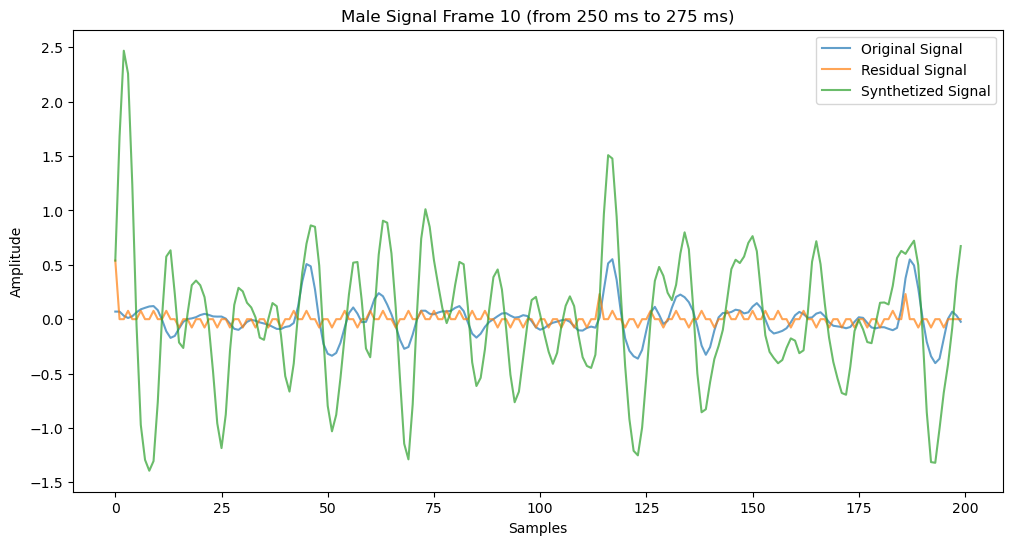

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df_simulated_male.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df_simulated_male.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df_simulated_male.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Male Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

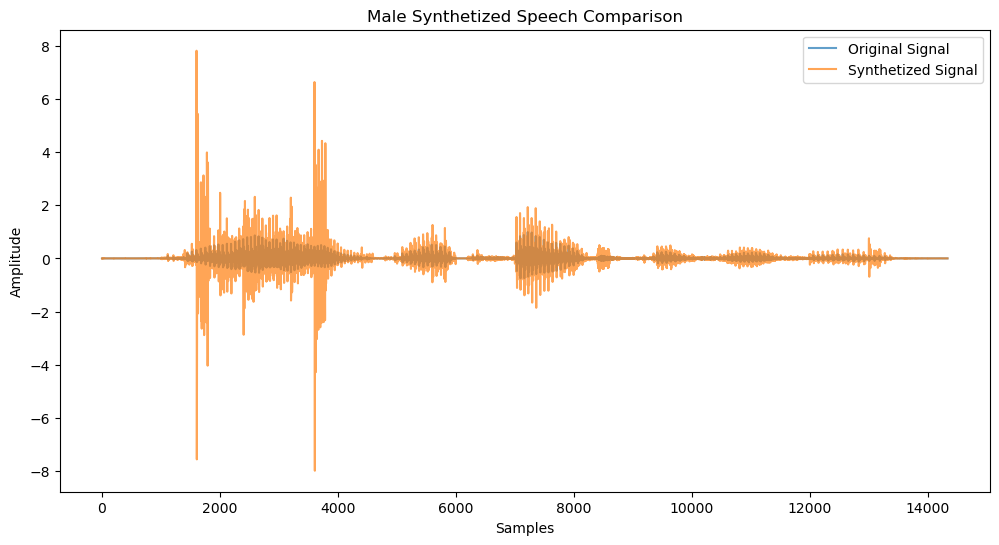

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_simulated_male["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_simulated_male["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Male Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [27]:
sf.write("old.wav", np.concatenate(df_simulated_male["Frame"]), simulated_male_sr)
sf.write("new.wav", np.concatenate(df_simulated_male["Synthetized Frame"]), simulated_male_sr)

### Different Example

In [28]:
QLP_BITS = 6
NORM_BITS = 12
RESID_BITS = 3

df_simulated_female, simulated_female_sr = codec(EXAMPLE_FEMALE_PATH)
duration = sum(df_simulated_female["Frame"].apply(len)) / simulated_male_sr
print("Budget:", df_simulated_female["Budget"].sum() / duration / 1000, "kb/s")

Budget: 11.062515484350483 kb/s


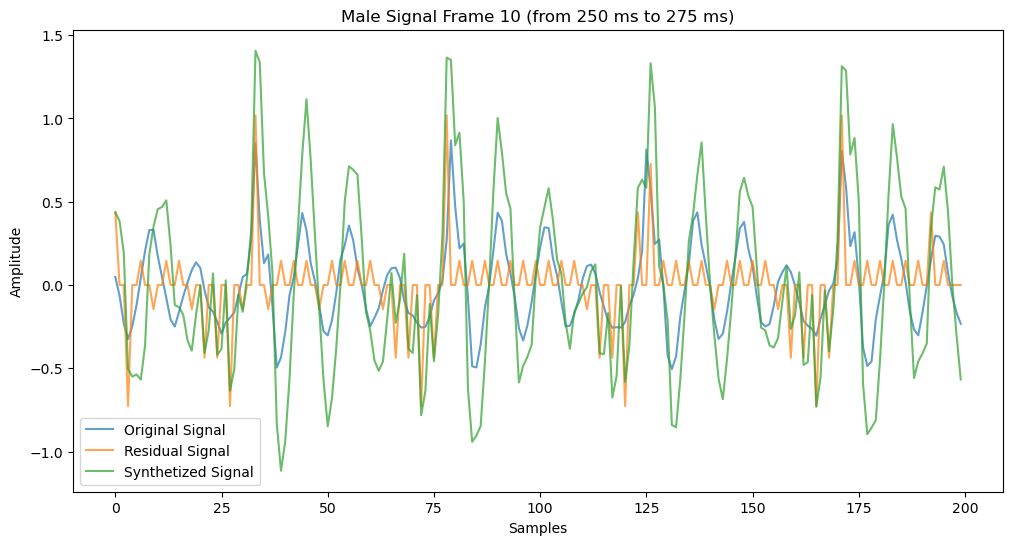

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df_simulated_female.loc[example_frame_idx, "Frame"], label="Original Signal", alpha=0.7)
plt.plot(df_simulated_female.loc[example_frame_idx, "Residual"], label="Residual Signal", alpha=0.7)
plt.plot(df_simulated_female.loc[example_frame_idx, "Synthetized Frame"], label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title(f"Male Signal Frame {example_frame_idx} (from "
          f"{example_frame_idx * FRAME_LENGTH * 1000:.0f} ms to "
          f"{(example_frame_idx + 1) * FRAME_LENGTH * 1000:.0f} ms)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

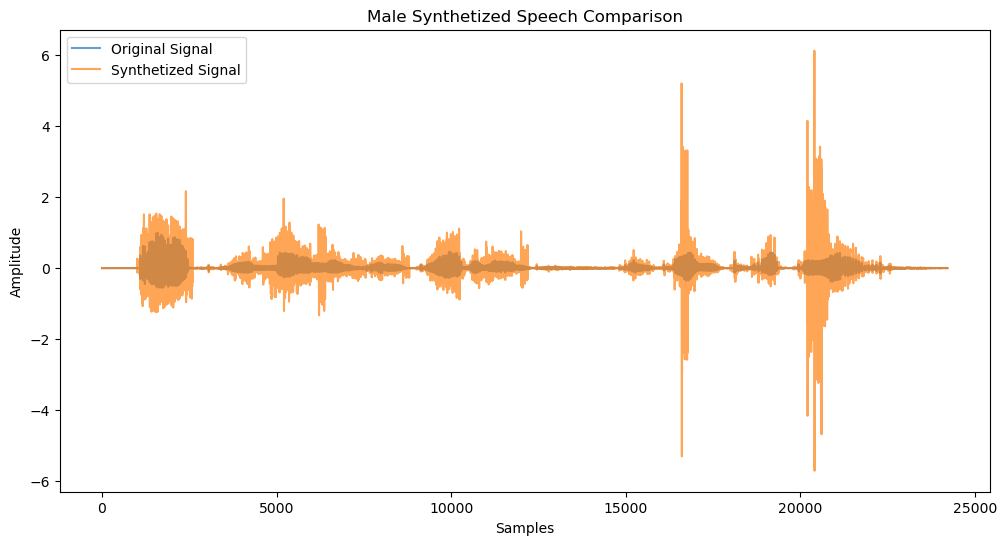

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(np.concatenate(df_simulated_female["Frame"]), label="Original Signal", alpha=0.7)
plt.plot(np.concatenate(df_simulated_female["Synthetized Frame"]), label="Synthetized Signal", alpha=0.7)
plt.legend()
plt.title("Male Synthetized Speech Comparison")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [31]:
def encode_file(file_path: Path, new_dir_path: Path) -> float:
    """
    Encodes and synthetizes the given file
    :param file_path: input audio path
    :param new_dir_path: directory where the encoded file should be written
    :return: budget estimation for the encoded audio in bits
    """
    new_file_path = new_dir_path / file_path.name
    df, sr = codec(file_path)
    sf.write(new_file_path, np.concatenate(df["Synthetized Frame"]), sr)
    
    dur = sum(df["Frame"].apply(len)) / sr
    return df["Budget"].sum() / dur

In [32]:
def encode_dir(dir_path: Path, print_budget=True):
    """
    Encodes and synthetizes every file in the given directory
    :param dir_path: path containing only audio files to be encoded
    :param print_budget: if true, prints the estimated budget for each file in kb/s
    """
    new_dir_path = dir_path.with_stem(dir_path.stem + "_enc")
    new_dir_path.mkdir(exist_ok=True)
    for file in dir_path.iterdir():
        budget = encode_file(file, new_dir_path)
        if print_budget:
            print(f"{file}:", budget / 1000, "kb/s")

In [33]:
QLP_BITS = 6
NORM_BITS = 16
RESID_BITS = 3

encode_dir(DATA_MALE_PATH)
encode_dir(DATA_FEMALE_PATH)

Male_sentences_8kHz/si923_8kHz.wav: 11.213026238083186 kb/s
Male_sentences_8kHz/si1175_8kHz.wav: 11.200654170335891 kb/s
Male_sentences_8kHz/si1364_8kHz.wav: 11.21109068627451 kb/s
Male_sentences_8kHz/si839_8kHz.wav: 11.215216398463316 kb/s
Male_sentences_8kHz/si745_8kHz.wav: 11.21484375 kb/s
Male_sentences_8kHz/si1899_8kHz.wav: 11.235853169413202 kb/s
Male_sentences_8kHz/si1024_8kHz.wav: 11.20138992900578 kb/s
Male_sentences_8kHz/si1010_8kHz.wav: 11.215216398463316 kb/s
Male_sentences_8kHz/si1230_8kHz.wav: 11.211092826890393 kb/s
Male_sentences_8kHz/si1039_8kHz.wav: 11.206087507926442 kb/s
Female_sentences_8kHz/sa1_8kHz.wav: 11.200478652933885 kb/s
Female_sentences_8kHz/si1149_8kHz.wav: 11.201932367149759 kb/s
Female_sentences_8kHz/si614_8kHz.wav: 11.210544571626778 kb/s
Female_sentences_8kHz/si978_8kHz.wav: 11.21483771251932 kb/s
Female_sentences_8kHz/si1434_8kHz.wav: 11.211450729927007 kb/s
Female_sentences_8kHz/sa2_8kHz.wav: 11.210914867769366 kb/s
Female_sentences_8kHz/si696_8kHz.